In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# Problem Statement:

You are tasked with predicting the trip price of a taxi ride based on various factors such as the distance traveled, time of day, day of the week, traffic conditions, weather conditions, and the base fare structure. The dataset includes the following features:

- Distance traveled (in km): The distance the taxi travels during the ride.
- Time of day: The time of day when the trip was initiated (e.g., Morning, Afternoon, Evening, Night).
- Day of the week: Whether the trip took place on a weekday or weekend.
- Passenger count: The number of passengers in the taxi.
- Traffic conditions: The level of traffic during the ride (e.g., Low, Medium, High).
- Weather: The weather conditions during the ride (e.g., Clear, Rain).
- Base fare: The starting fare for the taxi ride.
- Per km rate: The fare rate charged per kilometer traveled.
- Per minute rate: The fare rate charged per minute of the ride.
- Trip duration (in minutes): The total duration of the taxi ride.

**Goal:**
- Build a regression model that can accurately predict the trip price based on the above features. The model should handle missing values, categorical data (e.g., time of day, weather, traffic conditions), and numerical data (e.g., distance, base fare).

**Expected Outcome**:
- The trained model should be able to predict the taxi fare for a given ride, which can assist in fare estimation tools or help the company optimize pricing strategies based on various factors influencing the fare.



In [2]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\taxi_trip_pricing.csv")

In [3]:
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [4]:
df.shape

(1000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


**Observation**
- Total Entries: The dataset has 1000 entries.
- All columns except Trip_Price have 50 missing values, and Trip_Price has 49 missing values.
- The rest of the columns contain 950 non-null entries.


In [6]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

**Observation**
- All dataypes are correct format except passenger_count

In [7]:
df['Passenger_Count'] = df['Passenger_Count'].astype('Int64')

In [8]:
df['Passenger_Count'].dtypes

Int64Dtype()

- converted df['Passenger_Count'] to int64 bocoz int not support when null alues present in the columns

In [9]:
df.head(2)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1,High,Clear,NaN,0.62,0.43,40.57,NaN


**CHECK FOR MISSING VALUES**

In [10]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

**Observation**
- Traffic_Conditions: 50 missing values (950 non-null out of 1000).
- Weather: 50 missing values (950 non-null out of 1000).
- Base_Fare: 50 missing values (950 non-null out of 1000).
- Per_Km_Rate: 50 missing values (950 non-null out of 1000).
- Per_Minute_Rate: 50 missing values (950 non-null out of 1000).
- Trip_Duration_Minutes: 50 missing values (950 non-null out of 1000).
- Trip_Price: 49 missing values (951 non-null out of 1000).

**To handle the missing values in the output variable (Trip_Price), i will remove the recordS**

In [11]:
# Remove rows where 'Trip_Price' has missing values
df = df.dropna(subset=['Trip_Price'])

In [12]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              49
Day_of_Week              46
Passenger_Count          48
Traffic_Conditions       50
Weather                  46
Base_Fare                44
Per_Km_Rate              44
Per_Minute_Rate          49
Trip_Duration_Minutes    46
Trip_Price                0
dtype: int64

**Handle missing values from Input columns usin mean or median or mode because not have missing values information but cannot remove records becoz deleting input records may cause data loss**

In [13]:
# Handling missing values in numerical columns
df['Trip_Distance_km'] = df['Trip_Distance_km'].fillna(df['Trip_Distance_km'].mean())  
df['Base_Fare'] = df['Base_Fare'].fillna(df['Base_Fare'].mean())  
df['Per_Km_Rate'] = df['Per_Km_Rate'].fillna(df['Per_Km_Rate'].mean())  
df['Per_Minute_Rate'] = df['Per_Minute_Rate'].fillna(df['Per_Minute_Rate'].mean())  
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(df['Trip_Duration_Minutes'].mean())  

C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\3007298603.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Trip_Distance_km'] = df['Trip_Distance_km'].fillna(df['Trip_Distance_km'].mean())
C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\3007298603.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Base_Fare'] = df['Base_Fare'].fillna(df['Base_Fare'].mean())
C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\3007298603.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [14]:
df['Passenger_Count'] = df['Passenger_Count'].fillna(round(df['Passenger_Count'].mean())).astype(int)


C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\1396859630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Passenger_Count'] = df['Passenger_Count'].fillna(round(df['Passenger_Count'].mean())).astype(int)


In [15]:
# Handling missing values in categorical columns (impute with mode)
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Day_of_Week'] = df['Day_of_Week'].fillna(df['Day_of_Week'].mode()[0])
df['Traffic_Conditions'] = df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0])
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\2224748662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\2224748662.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day_of_Week'] = df['Day_of_Week'].fillna(df['Day_of_Week'].mode()[0])
C:\Users\SHRI\AppData\Local\Temp\ipykernel_15212\2224748662.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [16]:
# Verify if all missing values have been handled
print(df.isnull().sum())

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64


- Data is cleaned no null values present

**CHECK DUPLICATES**

In [17]:
df.duplicated().sum()

0

- No duplicates in given data

In [18]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.870000,Evening,Weekend,1,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.330000,Evening,Weekday,4,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,27.190998,Evening,Weekday,3,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.640000,Afternoon,Weekend,2,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


# One-Hot Encoding 

In [19]:
df = pd.get_dummies(df, columns=['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], drop_first=True)


In [20]:
df.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.350000,3,3.56,0.80,0.32,53.82,36.2624,False,True,False,False,True,False,False,False
2,36.870000,1,2.70,1.21,0.15,37.27,52.9032,True,False,False,True,False,False,False,False
3,30.330000,4,3.48,0.51,0.15,116.81,36.4698,True,False,False,False,True,False,False,False
4,27.190998,3,2.93,0.63,0.32,22.64,15.6180,True,False,False,False,False,False,False,False
5,8.640000,2,2.55,1.71,0.48,89.33,60.2028,False,False,False,True,False,True,False,False


In [21]:
df.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.350000,3,3.56,0.80,0.32,53.82,36.2624,False,True,False,False,True,False,False,False
2,36.870000,1,2.70,1.21,0.15,37.27,52.9032,True,False,False,True,False,False,False,False
3,30.330000,4,3.48,0.51,0.15,116.81,36.4698,True,False,False,False,True,False,False,False
4,27.190998,3,2.93,0.63,0.32,22.64,15.6180,True,False,False,False,False,False,False,False
5,8.640000,2,2.55,1.71,0.48,89.33,60.2028,False,False,False,True,False,True,False,False


In [22]:
df.corr()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
Trip_Distance_km,1.000000,-0.041813,0.031650,-0.013731,-0.032466,-0.023696,0.841360,-0.003190,-0.043826,-0.006912,-0.022042,-0.046369,-0.039728,0.057774,-0.040146
Passenger_Count,-0.041813,1.000000,0.024661,0.039345,0.037940,0.019514,-0.013172,0.017590,0.020339,0.031760,0.017393,-0.004028,-0.001282,0.024816,-0.012719
Base_Fare,0.031650,0.024661,1.000000,0.000818,-0.017322,0.009361,0.035156,-0.000186,-0.025892,0.036925,-0.026157,-0.030187,0.016473,-0.041656,-0.014730
Per_Km_Rate,-0.013731,0.039345,0.000818,1.000000,0.025157,0.028251,0.263598,0.035134,0.018759,0.050720,-0.045282,0.055736,-0.036561,0.012880,0.054674
Per_Minute_Rate,-0.032466,0.037940,-0.017322,0.025157,1.000000,-0.022396,0.134154,0.011786,-0.046923,0.038263,0.011686,0.005935,0.017286,-0.061094,0.034928
Trip_Duration_Minutes,-0.023696,0.019514,0.009361,0.028251,-0.022396,1.000000,0.219305,-0.030556,0.068038,-0.027064,-0.000727,0.009969,-0.006448,0.017036,0.022820
Trip_Price,0.841360,-0.013172,0.035156,0.263598,0.134154,0.219305,1.000000,-0.005943,-0.014219,-0.004531,-0.030137,-0.030416,-0.044407,0.038793,0.005764
Time_of_Day_Evening,-0.003190,0.017590,-0.000186,0.035134,0.011786,-0.030556,-0.005943,1.000000,-0.317693,-0.164244,-0.020564,-0.051322,0.002476,-0.010803,0.062321
Time_of_Day_Morning,-0.043826,0.020339,-0.025892,0.018759,-0.046923,0.068038,-0.014219,-0.317693,1.000000,-0.199711,-0.060837,0.041762,0.000377,-0.029049,-0.003275
Time_of_Day_Night,-0.006912,0.031760,0.036925,0.050720,0.038263,-0.027064,-0.004531,-0.164244,-0.199711,1.000000,0.043553,-0.026732,0.005800,-0.010466,-0.002277


In [23]:
columns_to_delete = [
    'Passenger_Count',
    'Base_Fare',
    'Per_Minute_Rate',
    'Trip_Duration_Minutes',
    'Time_of_Day_Evening',
    'Time_of_Day_Morning',
    'Time_of_Day_Night',
    'Day_of_Week_Weekend',
    'Traffic_Conditions_Low',
    'Traffic_Conditions_Medium',
    'Weather_Rain',
    'Weather_Snow'
]

# Drop the selected columns from the DataFrame
df = df.drop(columns=columns_to_delete)

- low corr() between input and output is less than orr equal to 0.2 delete that columns it will be helpful for regression

In [24]:
df

,Trip_Distance_km,Per_Km_Rate,Trip_Price
0,19.350000,0.800000,36.2624
2,36.870000,1.210000,52.9032
3,30.330000,0.510000,36.4698
4,27.190998,0.630000,15.6180
5,8.640000,1.710000,60.2028
...,...,...,...
995,5.490000,0.620000,34.4049
996,45.950000,0.610000,62.1295
997,7.700000,1.780000,33.1236
998,47.560000,0.820000,61.2090


In [25]:
df[['Trip_Distance_km', 'Per_Km_Rate']].corr()


,Trip_Distance_km,Per_Km_Rate
Trip_Distance_km,1.000000,-0.013731
Per_Km_Rate,-0.013731,1.000000


- Not high corr() betn input to input no need to delete column

In [26]:
df.isnull().sum()

Trip_Distance_km    0
Per_Km_Rate         0
Trip_Price          0
dtype: int64

In [27]:
df.skew()

Trip_Distance_km    2.323070
Per_Km_Rate         0.093373
Trip_Price          3.732561
dtype: float64

- input variable Trip_Distance_km  contain skewness 2.323070 need to apply transformation
- dont apply to the output variable

In [28]:
# Apply log transformation to 'Trip_Distance_km'

df['Trip_Distance_km'] = np.log1p(df['Trip_Distance_km'])  

In [29]:
df.skew()

Trip_Distance_km   -0.781797
Per_Km_Rate         0.093373
Trip_Price          3.732561
dtype: float64

- Now input variables are normally distributed
- No null values
- no missing values
- now this data is completely ready for Regression but first check colinearity, Homoscedasticity

# checking colinearity problem

only in input variables

<Axes: >

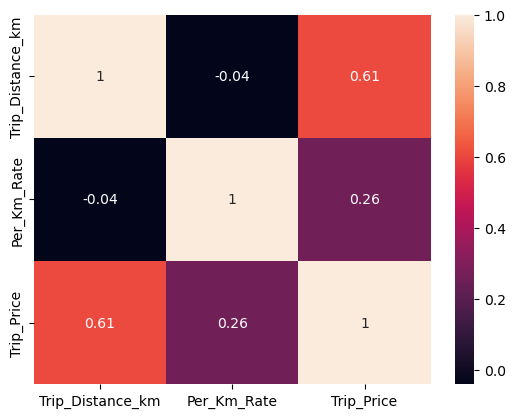

In [30]:
sns.heatmap(df.corr(), annot = True)

In [31]:
df.corr()

,Trip_Distance_km,Per_Km_Rate,Trip_Price
Trip_Distance_km,1.000000,-0.040395,0.607496
Per_Km_Rate,-0.040395,1.000000,0.263598
Trip_Price,0.607496,0.263598,1.000000


**Observation**
- **if the correlation betn any 2 independent variables is >= 5 then it is called as colinearity problem**
- **sloution**: drop 1 of them
- in this no colinearity problem

**Interpretation of VIF Values:**

- VIF = 1: No correlation between the predictor and other predictors.
- 1 < VIF < 5: Moderate correlation; no major issue for regression.
- VIF > 5 (or 10, depending on the threshold): High multicollinearity, meaning that the - predictor is highly correlated with other predictors, which can lead to instability in the regression model.

In [32]:
df.head(0)

,Trip_Distance_km,Per_Km_Rate,Trip_Price


In [33]:
import statsmodels.formula.api as smf 

rsq_Trip_Distance_km = smf.ols("Trip_Distance_km~Per_Km_Rate", data = df).fit().rsquared
vif_Trip_Distance_km = 1/(1 - rsq_Trip_Distance_km)

rsq_Per_Km_Rate = smf.ols("Per_Km_Rate~Trip_Distance_km", data = df).fit().rsquared
vif_Per_Km_Rate = 1/(1 - rsq_Per_Km_Rate)

#rsq_Trip_Duration_Minutes = smf.ols("Trip_Duration_Minutes~Per_Km_Rate+Trip_Distance_km", data = df).fit().rsquared
#vif_Trip_Duration_Minutes = 1/(1 - rsq_Trip_Duration_Minutes)


# storing vif_values t dataframe
d1 = {'Variables' : ['Trip_Distance_km', 'Per_Km_Rate'] , 
      'VIF' : [vif_Trip_Distance_km, vif_Per_Km_Rate]}
vif_frame = pd.DataFrame(d1)
vif_frame

,Variables,VIF
0,Trip_Distance_km,1.001634
1,Per_Km_Rate,1.001634


**Observation**
- VIF Values Near 1: All three variables—Trip_Distance_km, Per_Km_Rate, and Trip_Duration_Minutes—have very low VIF values (close to 1). This indicates that there is no significant multicollinearity between these variables. In other words:

- These variables are not highly correlated with each other.
- The presence of one variable does not inflate the variance of the others in the regression model.



**Now data is ready for regression**


# check for best random state number

**X and y**

In [34]:
X = df.drop(columns = ['Trip_Price'])
y = df['Trip_Price']

**To identify the best random state number**

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score


Train = []
CV = []

for i in range(0,10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Training R2 Score
    ypred_train = model.predict(X_train)

    Train.append(r2_score(y_train, ypred_train))

    # Cross-validation score
    CV.append(cross_val_score(model, X_train, y_train, cv=5).mean())

        
# Create a DataFrame after the loop
em = pd.DataFrame({'Train': Train, 'CV': CV})

# Filtering based on condition
gm = em[abs(em['Train'] - em['CV']) <= 0.05]

rs = gm[gm['CV'] == gm['CV'].max()].index.tolist()[0]
print("Best random number is:", rs)


Best random number is: 5


# Best random number is: 5

In [36]:
df.head()

,Trip_Distance_km,Per_Km_Rate,Trip_Price
0,3.013081,0.80,36.2624
2,3.634159,1.21,52.9032
3,3.444576,0.51,36.4698
4,3.339003,0.63,15.6180
5,2.265921,1.71,60.2028


In [37]:
df.to_excel('cleaned_Taxi_Price_data.xlsx', index = False)

In [38]:
pwd

'E:\\Data Science by SRK\\Machine_learning\\project\\Taxi_price_prediction_xgboost'